In [1]:
print("hello world")

hello world


In [2]:
from models.analyzer import FeatureSelectionAnalyzer

In [3]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

In [4]:
data = pd.read_excel("./data_raw/DataSet_V49 (2).xlsx")

In [292]:
for i in sorted(data.columns):
    print(i)

APACHE сутки ПОСЛЕ развития SOFA 8 и более
APACHE сутки до развития SOFA 8 и более
Age
Apache II
BEArtMax
BEArtMax (a)
BEArtMax (b)
BEArtMin
BEArtMin (a)
BEArtMin (b)
BEVenMax
BEVenMax (a)
BEVenMax (b)
BEVenMin
BEVenMin (a)
BEVenMin (b)
BLR (базофилы абс/лимфоциты абс)
BNP
BNP (a)
BNP (b)
Bypass#
CADILLAC
CADILLAC (Высокий риск)
CADILLAC (Низкий риск)
CADILLAC (Средний риск)
Cегментоядерные нейтрофилы(%)(a)
Cегментоядерные нейтрофилы(%)(b)
EDV
ELR %
ELR (эозинофилы абс/лимфоциты абс
ENR (эозин абс/нейтрофилы абс)
FLR (fibr/L abs)
GLR (глюкоза мг/дл / лимф абс)
GRACE (Высокий риск)
GRACE (Низкий риск)
GRACE (Средний риск)
GRACE(Общее)
GRACE(Общее)>140
GRACE(Общее)>156
HCO3ArtMax
HCO3ArtMax (a)
HCO3ArtMax (b)
HCO3ArtMin
HCO3ArtMin (a)
HCO3ArtMin (b)
HCO3VenMax
HCO3VenMax (a)
HCO3VenMax (b)
HCO3VenMin
HCO3VenMin (a)
HCO3VenMin (b)
Hb(a)
LACTartMax
LACTartMax (a)
LACTartMax (b)
LACTartMin
LACTartMin (a)
LACTartMin (b)
LMR (лимфоциты абс/моноциты абс)
La1
La2
LactVenMax
LactVenMax (a)
LactV

In [289]:
for col in data.columns:
    if "GRACE" in col or "TIMI" in col or "APACHE" in col or "SOFA" in col:
        print(col)

TIMI
GRACE(Общее)
GRACE(Общее)>140
GRACE(Общее)>156
TIMI (Летальность)
GRACE (Низкий риск)
GRACE (Средний риск)
GRACE (Высокий риск)
TIMI (Летальность) (Низкий риск)
TIMI (Летальность) (Средний риск)
TIMI (Летальность) (Высокий риск)
Дата и время развития SOFA 8 и более
Часов в ОРИТ ДО развития SOFA 8
Часов в ОРИТ ПОСЛЕ развития SOFA 8
Максимальный прокальцитонин за сутки до развития SOFA 8
Максимальный ЛАКТАТ артерия за сутки до развития SOFA 8
Максимальный ЛАКТАТ вена за сутки до развития SOFA 8
Максимальный ЛАКТАТ артерия за сутки после развития SOFA 8
Максимальный ЛАКТАТ вена за сутки после развития SOFA 8
SOFA первый раз больше или равна 8 баллам
SOFA до развития 8 и более баллов
Используемый антибиотик ДО развития SOFA 8 и более
Левофлоксацин антибиотик ДО развития SOFA 8 и более
Линезолид антибиотик ДО развития SOFA 8 и более
Меропенем антибиотик ДО развития SOFA 8 и более
Метронидазол антибиотик ДО развития SOFA 8 и более
Моксифлоксацин антибиотик ДО развития SOFA 8 и более
Ниф

In [5]:
data.dropna(subset=['Смерть'], inplace=True)
data['Смерть'] = data['Смерть'].map({'Да': 1, 'Нет': 0})

In [5]:
cols = [
    "Смерть",
    "Age",
    "Sex",
    "Рост",
    "Вес",
    "Индекс массы тела", 
    "Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",
    "Инфаркт миокарда со стентированием в анамнезе",
    "ОНМК (иш) в анамнезе",
    "ОНМК (гем) в анамнезе",
    "Стентирование в анамнезе",
    "Открытая перация на сердце в анамнезе",
    "ГБ стадия",
    "ГБ риск",
    "АГ",
    "СД",
    "ХБП",
    "ЯБ",
    "МКБ",
    "ЖКБ",
    "ХОБЛ (Новый столбец)",
    "Курит",
    "Экстракардиальная артериопатия",
    "Плохая мобильность",
    "Стенокардия (ИБ)",
    "Стенокардия форма(ИБ)",
    "Стенокардия ФК (ИБ)",
    "Стенокардия в диагнозе при поступлении",
    "ПИКС в диагнозе при поступлении",
    "Форма ФП",
    "ФП постоянная форма",
    "ФП при окс (до чкв)", 
    "ЧКВ",
    "Инфаркт-зависимая артерия",
    "Поражение ствола",
    "Количество пораженных сосудов(Syntax)",
    "Количество пораженных сосудов(Значимость)",
    "TIMI",
    "Класс ОСН по Killip",
    "ХСН стадия",
    "ФЖ",
    "Пробежки ЖТ",
    "Рецидивирующая ЖТ",
    "Срочность",
    "Экстренная операция(ИБ)(Новый)",
    "Вид операции(ИБ)(Новый)",
    "Тромболизис",
    "Медицинская помощь оказана за первые 4 часа",
    "Гипертоническая болезнь",
    "ФВ < 40",
    "А-В блокада",
    "А-В блокада (степень)",
]

In [6]:
category_cols = [
    "Sex", "STEMI", "ЧКВ", "Вид STEMI", "Инфаркт-зависимая артерия",
    "Поражение ствола","Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",'Инфаркт миокарда со стентированием в анамнезе',
    'ОНМК (иш) в анамнезе', 'ОНМК (гем) в анамнезе','Стентирование в анамнезе',
    'Тромболизис', 'Форма ФП', 'Калий', 'Дилатация предсердий','ФП b (после чкв)',
    'ФП a (в анамнезе)', 'ФП при окс (до чкв)', 'ФП постоянная форма', 'ФЖ',
    'Пробежки ЖТ', 'Рецидивирующая ЖТ', 'MKB', 'Класс ОСН по Killip',
    'ХСН стадия', 'АГ', 'Стенокардия (ИБ)', 'Стенокардия форма(ИБ)',
    'Стенокардия ФК (ИБ)', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ЖКБ', 'Стеноз аортального клапана (степень)',
    'Недостаточность трикуспидального клапана (степень)', 'НПВ', 'Экстренная операция(ИБ)(Новый)',
    'Вид операции(ИБ)(Новый)', 'повторные операции','Тип первой операции БД',
    'Тип повторной операции', 'GRACE(Общее)>140', 'интегрилин|эптифибатид|коромакс|агграстат',
    'Экстракардиальная артериопатия', 'Плохая мобильность', 'Открытая перация на сердце в анамнезе',
    'Срочность', 'Сопутствующие1', 'Сопутствующие2', 'Тропонин 1 > 0.1 (b)', 'Тропонин 1 > 0.1 (a)',
    'Тропонин 1 > 0.1', 'Smoking', 'Протокол коронарографии', 'Аортальный стеноз (Градиент)',
    'Аортальный стеноз (Заключение)', 'ХОБЛ (Новый столбец)', 'Коррекция А-В блокады',
    'Исход А-В блокады', 'Начало А-В блокады (До/после ЧКВ)', 'А-В блокада',
    'Стенокардия в диагнозе при поступлении', 'ПИКС в диагнозе при поступлении',
    'Инфаркт-зависимая артерия(Огригированная)', 'Инфаркт-зависимая артерия(Огригированная)2',
    'Ишемический инсульт (Выгрузка из ИБ - временный столбец)', 'Геморрагический инсульт (Выгрузка из ИБ - временный столбец)',
    'Инсульт (Выгрузка из ИБ - временный столбец)', 'Курит', 'GRACE(Общее)>156', 'Отек легких(b)',
    'Отек легких(a)', 'Отек легких', 'Медицинская помощь оказана за первые 4 часа',
    'Гипертоническая болезнь', 'ФВ < 40', 'CADILLAC (Низкий риск)', 'CADILLAC (Средний риск)',
    'CADILLAC (Высокий риск)', 'РЕКОРД (Низкий риск)', 'РЕКОРД (Высокий риск)',
    'GRACE (Низкий риск)', 'GRACE (Средний риск)', 'GRACE (Высокий риск)',
    'TIMI (Летальность) (Низкий риск)', 'TIMI (Летальность) (Средний риск)',
    'TIMI (Летальность) (Высокий риск)', 'PAMI (Низкий риск)', 'PAMI (Средний риск)',
    'PAMI (Высокий риск)', 'А-В блокаДа (Новый)', 'А-В блокада (степень)',
    'Используемый антибиотик ДО развития SOFA 8 и более',
    'Левофлоксацин антибиотик ДО развития SOFA 8 и более',
    'Линезолид антибиотик ДО развития SOFA 8 и более',
    'Меропенем антибиотик ДО развития SOFA 8 и более',
    'Метронидазол антибиотик ДО развития SOFA 8 и более',
    'Моксифлоксацин антибиотик ДО развития SOFA 8 и более',
    'Нифуроксазид антибиотик ДО развития SOFA 8 и более',
    'Фосфомицин антибиотик ДО развития SOFA 8 и более',
    'Цефазолин антибиотик ДО развития SOFA 8 и более',
    'Сульбактам антибиотик ДО развития SOFA 8 и более',
    'Цефоперазон антибиотик ДО развития SOFA 8 и более',
    'Цефтриаксон антибиотик ДО развития SOFA 8 и более',
    'Антибиотик после развития SOFA 8 и более',
    'Моксифлоксацин после развития SOFA 8 и более',
    'Левофлоксацин после развития SOFA 8 и более',
    'Азитромицин после развития SOFA 8 и более',
    'Линезолид после развития SOFA 8 и более',
    'Меропенем после развития SOFA 8 и более',
    'Метронидазол после развития SOFA 8 и более',
    'Нифуроксазид после развития SOFA 8 и более',
    'Фосфомицин после развития SOFA 8 и более',
    'Цефазолин после развития SOFA 8 и более',
    'Сульбактам после развития SOFA 8 и более',
    'Цефепим после развития SOFA 8 и более',
    'Цефтриаксон после развития SOFA 8 и более',
    'ИВЛ', 'Вазопрессорная поддержка', 'Адреналин',
    'Добутамин', 'Допмин', 'Норадреналин', 'Левосимендан',
    'Мезатон', 'UA (нестабильная стенокардия)','Синдромный диагноз','Смерть'
]

In [7]:
cols_to_delete = [
    "Код пациента", "Name", "Дата STEMI", "Дата направления (Общий анализ крови)", 
    "Дата взятия биоматериала (Общий анализ крови)", "Дата выполнения (Общий анализ крови)", 
    "Дата направления (Общий анализ крови-экспрес)", "Дата взятия биоматериала (Общий анализ крови-экспрес)",
    "Дата выполнения (Общий анализ крови-экспрес)", "Начало операции(ИБ)(Новый)", "Конец операции(ИБ)(Новый)", 
    "дата поступления", "дата выписки", "дата смерти", "Исход заболевания", "Поступление в реанимацию", 
    "Выписка из реанимации", "Файл(Анализы)", "Файл(ИБ)","Наличие в БД", "Наличие в файле", "Bypass#", 
    "Повторная оперция", "Смерть в реанимации", "Причина смерти", "Осложнения", "SmokeIndex", "Ход операции", 
    "Общий анализ крови раньше операции", "Общий анализ крови_экспресс раньше операции", "Отделение", 
    "Запись требует проверки", "Индекс курения", "Летальный исход икка", "Диагноз", 
    "Дата и время развития SOFA 8 и более", "Время введения первого антибиотика", 
    "Набор данных (Данные Кокарев)", "Unnamed: 344", "В базе данных", 
    "SYNTAX Score", "ХСН фк", "КДР ЛЖ", "КСР ЛЖ", "ДАД(a)", "Кардиогенный шок",
    'длительность нахождения в стационаре',
    'GRACE(Общее)>140',
    'GRACE(Общее)>156',
    'Отек легких(b)',
    'Отек легких(a)', 'Отек легких',
    'CADILLAC (Низкий риск)', 'CADILLAC (Средний риск)',
    'CADILLAC (Высокий риск)', 'РЕКОРД (Низкий риск)', 'РЕКОРД (Высокий риск)',
    'GRACE (Низкий риск)', 'GRACE (Средний риск)', 'GRACE (Высокий риск)',
    'TIMI (Летальность) (Низкий риск)', 'TIMI (Летальность) (Средний риск)',
    'TIMI (Летальность) (Высокий риск)', 'PAMI (Низкий риск)', 'PAMI (Средний риск)',
    'PAMI (Высокий риск)',
    'МКБ', 'ЖКБ',
    'Протокол коронарографии',
    'Класс ОСН по Killip',
    'ФВ < 40',
    "Мочевина(a)",
    'Используемый антибиотик ДО развития SOFA 8 и более',
    'Левофлоксацин антибиотик ДО развития SOFA 8 и более',
    'Линезолид антибиотик ДО развития SOFA 8 и более',
    'Меропенем антибиотик ДО развития SOFA 8 и более',
    'Метронидазол антибиотик ДО развития SOFA 8 и более',
    'Моксифлоксацин антибиотик ДО развития SOFA 8 и более',
    'Нифуроксазид антибиотик ДО развития SOFA 8 и более',
    'Фосфомицин антибиотик ДО развития SOFA 8 и более',
    'Цефазолин антибиотик ДО развития SOFA 8 и более',
    'Сульбактам антибиотик ДО развития SOFA 8 и более',
    'Цефоперазон антибиотик ДО развития SOFA 8 и более',
    'Цефтриаксон антибиотик ДО развития SOFA 8 и более',
    'Антибиотик после развития SOFA 8 и более',
    'Моксифлоксацин после развития SOFA 8 и более',
    'Левофлоксацин после развития SOFA 8 и более',
    'Азитромицин после развития SOFA 8 и более',
    'Линезолид после развития SOFA 8 и более',
    'Меропенем после развития SOFA 8 и более',
    'Метронидазол после развития SOFA 8 и более',
    'Нифуроксазид после развития SOFA 8 и более',
    'Фосфомицин после развития SOFA 8 и более',
    'Цефазолин после развития SOFA 8 и более',
    'Сульбактам после развития SOFA 8 и более',
    'Цефепим после развития SOFA 8 и более',
    'Цефтриаксон после развития SOFA 8 и более',
    "TIMI",
    "GRACE(Общее)",
    "GRACE(Общее)>140",
    "GRACE(Общее)>156",
    "TIMI (Летальность)",
    "GRACE (Низкий риск)",
    "GRACE (Средний риск)",
    "GRACE (Высокий риск)",
    "TIMI (Летальность) (Низкий риск)",
    "TIMI (Летальность) (Средний риск)",
    "TIMI (Летальность) (Высокий риск)",
    "Дата и время развития SOFA 8 и более",
    "Часов в ОРИТ ДО развития SOFA 8",
    "Часов в ОРИТ ПОСЛЕ развития SOFA 8",
    "Максимальный прокальцитонин за сутки до развития SOFA 8",
    "Максимальный ЛАКТАТ артерия за сутки до развития SOFA 8",
    "Максимальный ЛАКТАТ вена за сутки до развития SOFA 8",
    "Максимальный ЛАКТАТ артерия за сутки после развития SOFA 8",
    "Максимальный ЛАКТАТ вена за сутки после развития SOFA 8",
    "SOFA первый раз больше или равна 8 баллам",
    "SOFA до развития 8 и более баллов",
    "Используемый антибиотик ДО развития SOFA 8 и более",
    "Левофлоксацин антибиотик ДО развития SOFA 8 и более",
    "Линезолид антибиотик ДО развития SOFA 8 и более",
    "Меропенем антибиотик ДО развития SOFA 8 и более",
    "Метронидазол антибиотик ДО развития SOFA 8 и более",
    "Моксифлоксацин антибиотик ДО развития SOFA 8 и более",
    "Нифуроксазид антибиотик ДО развития SOFA 8 и более",
    "Фосфомицин антибиотик ДО развития SOFA 8 и более",
    "Цефазолин антибиотик ДО развития SOFA 8 и более",
    "Сульбактам антибиотик ДО развития SOFA 8 и более",
    "Цефоперазон антибиотик ДО развития SOFA 8 и более",
    "Цефтриаксон антибиотик ДО развития SOFA 8 и более",
    "Количество часов применения антибиотика ДО развития SOFA 8 и более",
    "Антибиотик после развития SOFA 8 и более",
    "Моксифлоксацин после развития SOFA 8 и более",
    "Левофлоксацин после развития SOFA 8 и более",
    "Азитромицин после развития SOFA 8 и более",
    "Линезолид после развития SOFA 8 и более",
    "Меропенем после развития SOFA 8 и более",
    "Метронидазол после развития SOFA 8 и более",
    "Нифуроксазид после развития SOFA 8 и более",
    "Фосфомицин после развития SOFA 8 и более",
    "Цефазолин после развития SOFA 8 и более",
    "Сульбактам после развития SOFA 8 и более",
    "Цефепим после развития SOFA 8 и более",
    "Цефтриаксон после развития SOFA 8 и более",
    "Через сколько часов после развития SOFA 8 и более был введен антибиотик",
    "APACHE сутки до развития SOFA 8 и более",
    "APACHE сутки ПОСЛЕ развития SOFA 8 и более",
    "АД среднее за сутки до развития SOFA 8",
    "Среднее АД 1 сутки в орит",
    "Среднее АД 3 сутки в орит",
    "Среднее АД 7 сутки в орит",
    "Среднее ЧСС 1 сутки",
    "Среднее ЧСС 3 сутки",
    "Среднее ЧСС 7 сутки",
    "Экстренная операция(ИБ)(Новый)"
        
]

In [8]:
for col in cols_to_delete:
    try:
        data.drop([col], axis=1, inplace=True)
    except Exception as e: 
        pass 

In [9]:
for col in category_cols:
    if col not in cols_to_delete:
        data[col] = data[col].fillna('missing').astype('str')
        data[col] = data[col].astype('category')

In [10]:
X = data.drop(["Смерть"], axis=1)
y = data["Смерть"].astype('int')

In [11]:
def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace('[', '_').replace(']', '_').replace('<', '_lt_')
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace('>', '_gt_').replace(' ', '_').replace(':', '_')
        clean_col = clean_col.replace('(', '_').replace(')', '_').replace(',', '_')
        clean_col = clean_col.replace('{', '_').replace('}', '_').replace('|', '_')
        # Удаляем последовательные подчеркивания
        clean_col = '_'.join(filter(None, clean_col.split('_')))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip('_')
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = 'f_' + clean_col
        new_columns.append(clean_col)
    
    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean

# Применяем к вашим данным
X_clean = clean_column_names(X)

In [12]:
cat_features = []
for col in X_clean.columns:
    try:
        if X_clean[col].dtype.name == 'category': 
            cat_features.append(col)
    except Exception as e:
        print(col)

In [14]:
cat_features

['Sex',
 'STEMI',
 'ЧКВ',
 'Вид_STEMI',
 'Инфаркт-зависимая_артерия',
 'Поражение_ствола',
 'Инфаркт_миокарда_в_анамнезе_lt_3',
 'Инфаркт_миокарда_в_анамнезе_gt_3',
 'Инфаркт_миокарда_со_стентированием_в_анамнезе',
 'ОНМК_иш_в_анамнезе',
 'ОНМК_гем_в_анамнезе',
 'Стентирование_в_анамнезе',
 'Тромболизис',
 'Форма_ФП',
 'Калий',
 'Дилатация_предсердий',
 'ФП_b_после_чкв',
 'ФП_a_в_анамнезе',
 'ФП_при_окс_до_чкв',
 'ФП_постоянная_форма',
 'ФЖ',
 'Пробежки_ЖТ',
 'Рецидивирующая_ЖТ',
 'MKB',
 'Класс_ОСН_по_Killip',
 'ХСН_стадия',
 'АГ',
 'Стенокардия_ИБ',
 'Стенокардия_форма_ИБ',
 'Стенокардия_ФК_ИБ',
 'СД',
 'ХБП',
 'ЯБ',
 'МКБ',
 'ЖКБ',
 'Стеноз_аортального_клапана_степень',
 'Недостаточность_трикуспидального_клапана_степень',
 'НПВ',
 'Экстренная_операция_ИБ_Новый',
 'Вид_операции_ИБ_Новый',
 'повторные_операции',
 'Тип_первой_операции_БД',
 'Тип_повторной_операции',
 'GRACE_Общее_gt_140',
 'интегрилин_эптифибатид_коромакс_агграстат',
 'Экстракардиальная_артериопатия',
 'Плохая_мобильно

In [13]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [14]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm
import time

In [15]:
scale_pos_weight = len(y[y == 0]) / max(1, len(y[y == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

print(f"scale pos weight: {scale_pos_weight}")

scale pos weight: 27.89217391304348


In [17]:
list(X.select_dtypes(include=['category']).columns)

['Sex',
 'STEMI',
 'ЧКВ',
 'Вид STEMI',
 'Инфаркт-зависимая артерия',
 'Поражение ствола',
 'Инфаркт миокарда в анамнезе (<3)',
 'Инфаркт миокарда в анамнезе (>3)',
 'Инфаркт миокарда со стентированием в анамнезе',
 'ОНМК (иш) в анамнезе',
 'ОНМК (гем) в анамнезе',
 'Стентирование в анамнезе',
 'Тромболизис',
 'Форма ФП',
 'Калий',
 'Дилатация предсердий',
 'ФП b (после чкв)',
 'ФП a (в анамнезе)',
 'ФП при окс (до чкв)',
 'ФП постоянная форма',
 'ФЖ',
 'Пробежки ЖТ',
 'Рецидивирующая ЖТ',
 'MKB',
 'Класс ОСН по Killip',
 'ХСН стадия',
 'АГ',
 'Стенокардия (ИБ)',
 'Стенокардия форма(ИБ)',
 'Стенокардия ФК (ИБ)',
 'СД',
 'ХБП',
 'ЯБ',
 'МКБ',
 'ЖКБ',
 'Стеноз аортального клапана (степень)',
 'Недостаточность трикуспидального клапана (степень)',
 'НПВ',
 'Экстренная операция(ИБ)(Новый)',
 'Вид операции(ИБ)(Новый)',
 'повторные операции',
 'Тип первой операции БД',
 'Тип повторной операции',
 'GRACE(Общее)>140',
 'интегрилин|эптифибатид|коромакс|агграстат',
 'Экстракардиальная артериопати

In [16]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
    missing=np.nan,  # явно указываем, что NaN - это пропуски
    random_state=42,
    eval_metric='logloss',  # для бинарной классификации
    tree_method='auto',  # автоматический выбор метода обучения
    enable_categorical=True
)

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    class_weight=class_weight_dict,  # борьба с дисбалансом
    random_state=42,
    verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    # early_stopping_rounds=50  # задается при инициализации
)

cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
    random_state=42,
    verbose=False,
    eval_metric='Logloss',
    early_stopping_rounds=50,  # задается при инициализации
    # cat_features=list(X.select_dtypes(include=['category']).columns)
)

In [17]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(cat_model, max_features=None, metric='roc_auc')

=== FORWARD SELECTION ===
Запуск Forward Selection...


  0%|          | 1/343 [00:35<3:20:28, 35.17s/it, roc_auc=0.7994, Features=1]

Step 1: Добавлен признак 'Креатинин', roc_auc: 0.7994


  1%|          | 2/343 [01:16<3:41:05, 38.90s/it, roc_auc=0.8714, Features=2]

Step 2: Добавлен признак 'СДЛА', roc_auc: 0.8714


...

Step 14: Добавлен признак 'Макс_АД_7_сут', roc_auc: 0.9701


  4%|▍         | 15/343 [13:22<5:25:59, 59.63s/it, roc_auc=0.9714, Features=15]

Step 15: Добавлен признак 'ЧСС_а', roc_auc: 0.9714


  4%|▍         | 15/343 [14:24<5:15:04, 57.64s/it, roc_auc=0.9714, Features=15]

Step 16: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 15


In [18]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(cat_model, min_features=1, metric='roc_auc')


=== BACKWARD ELIMINATION ===
Запуск Backward Elimination...


  0%|          | 1/342 [07:13<41:06:22, 433.97s/it, roc_auc=0.9648, Features=342]

Step 1: Удален признак 'МНО_a', roc_auc: 0.9648


  0%|          | 1/342 [14:28<82:16:56, 868.67s/it, roc_auc=0.9648, Features=342]

Step 2: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 342



=== СРАВНЕНИЕ МЕТОДОВ ===


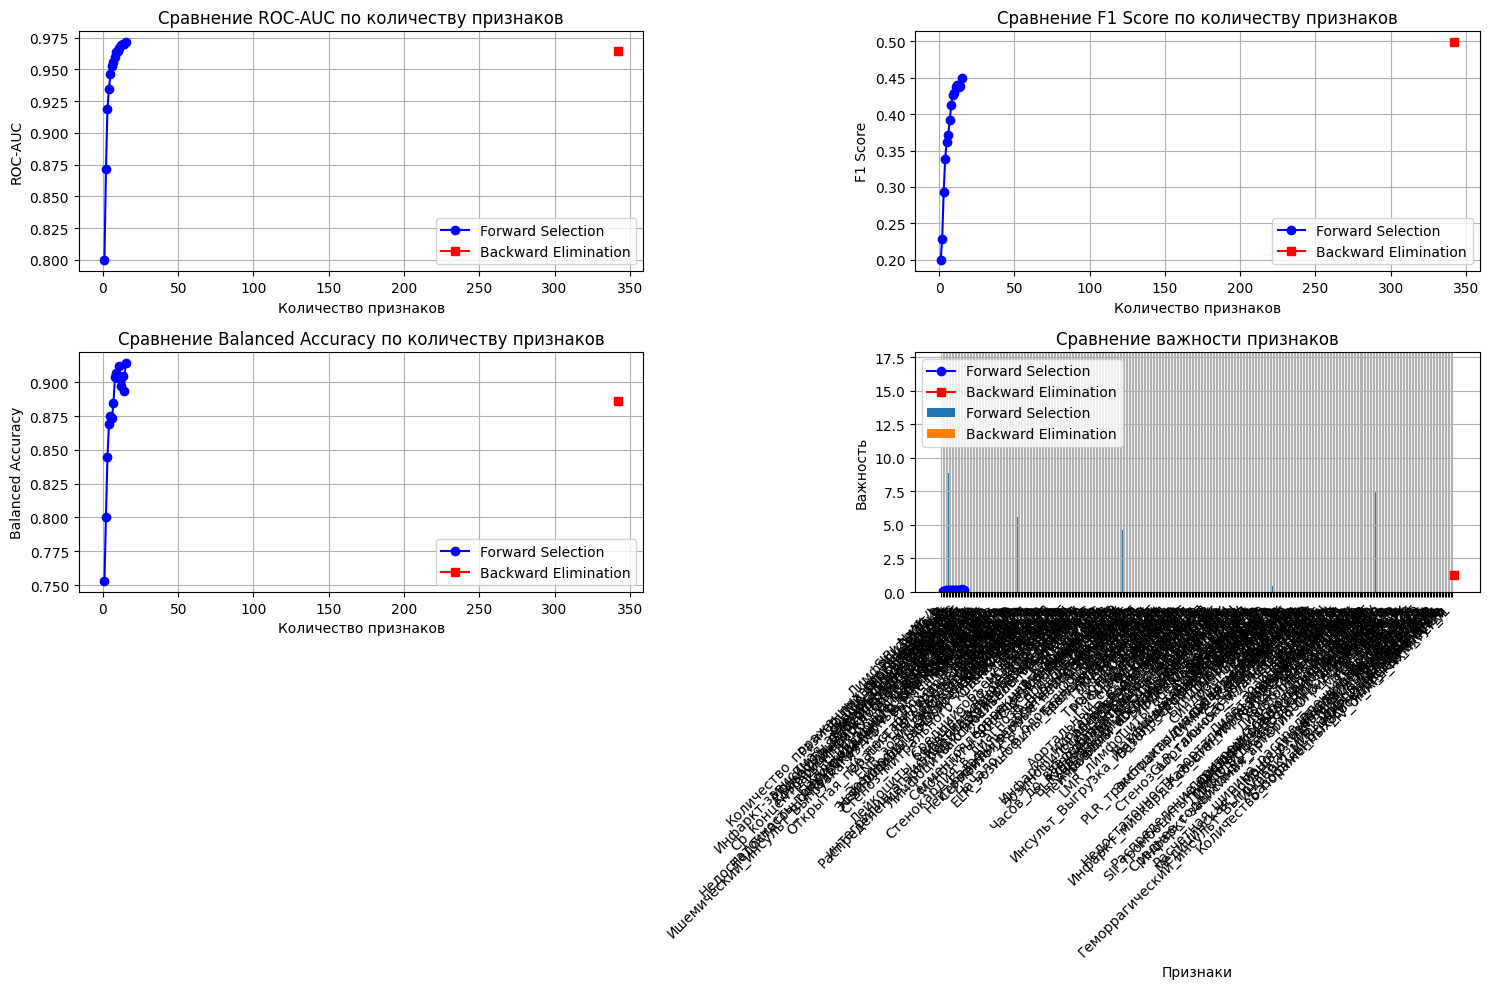

In [19]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [20]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 15 признаков) ===
По Balanced Accuracy score: 0.5000 (F1=0.9143)
По Youden's J: 0.5069


In [21]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 342 признаков) ===
По Balanced Accuracy score: 0.2900 (F1=0.9074)
По Youden's J: 0.2927



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


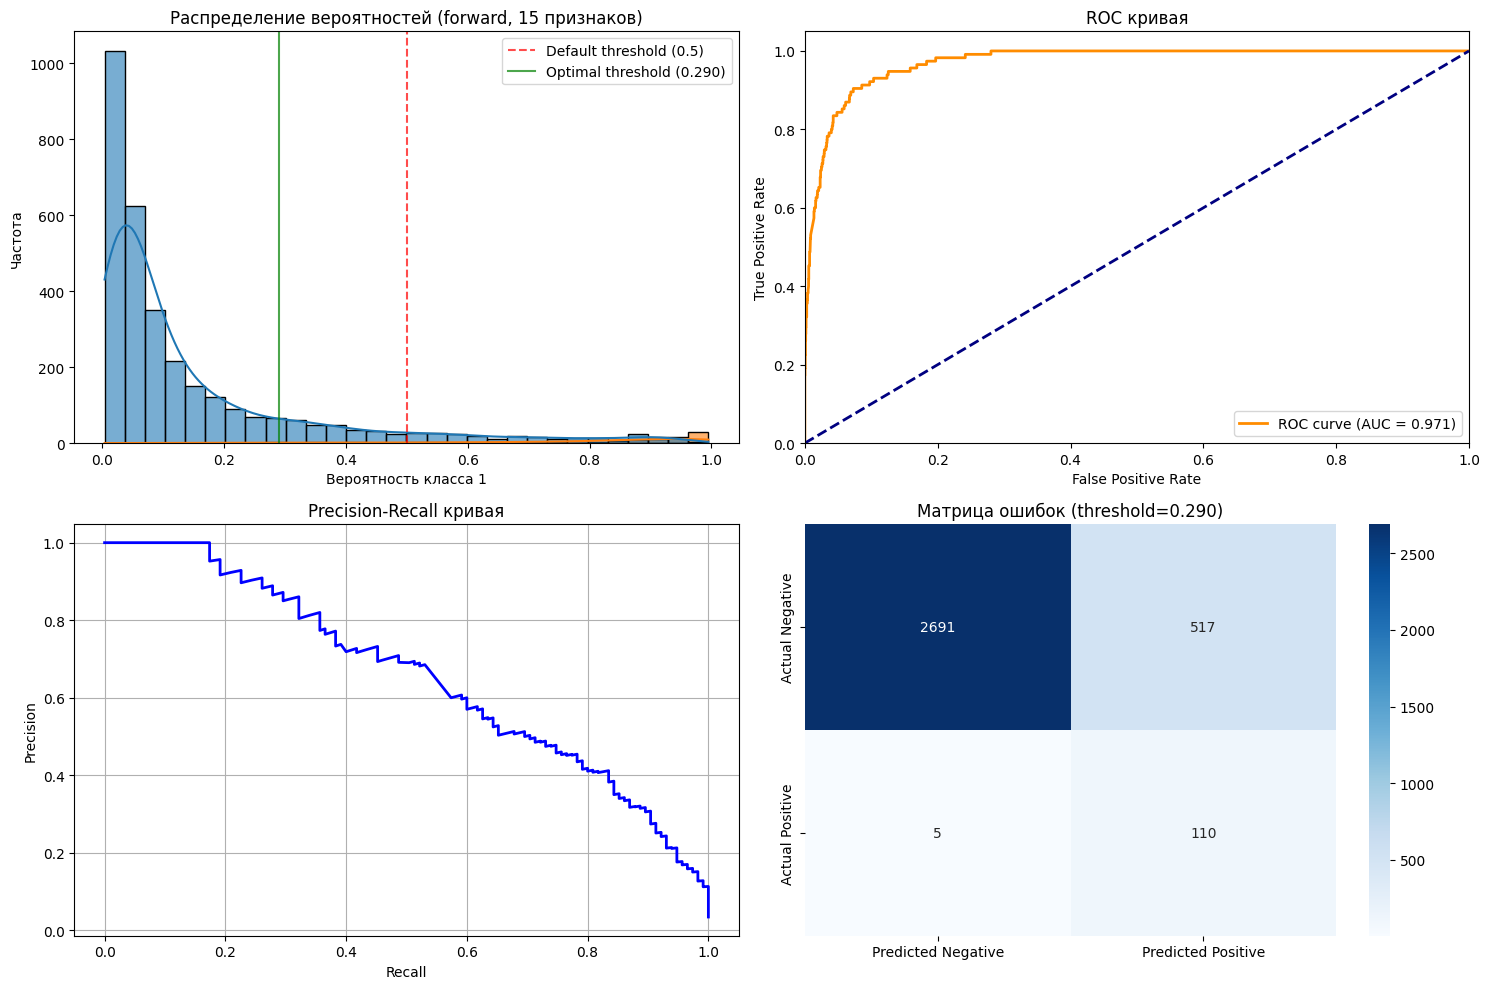

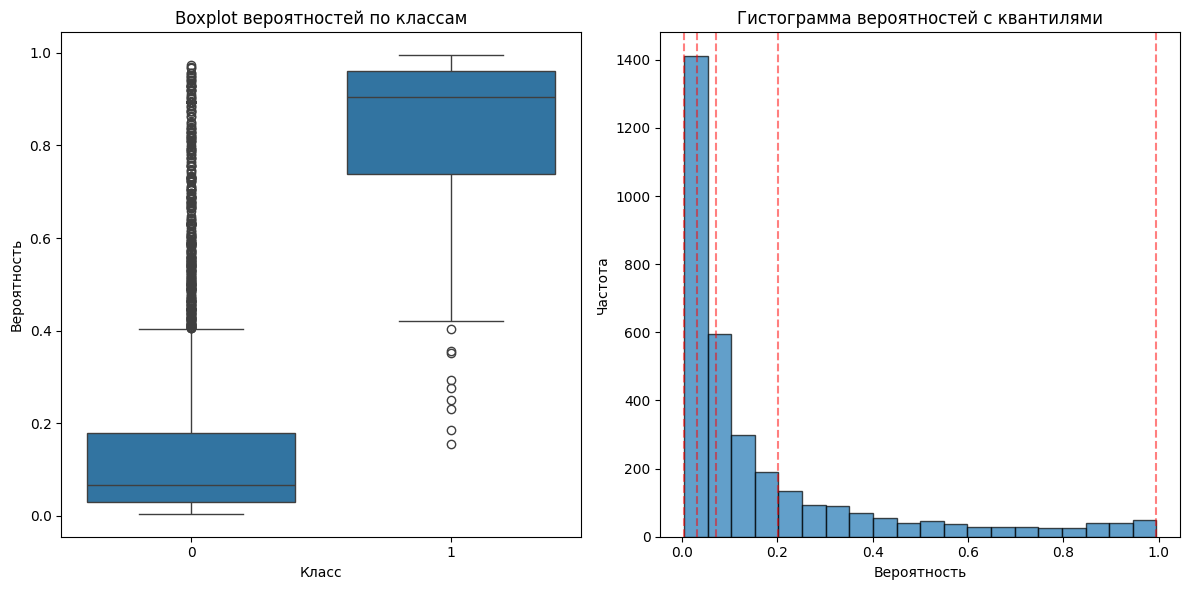

In [22]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


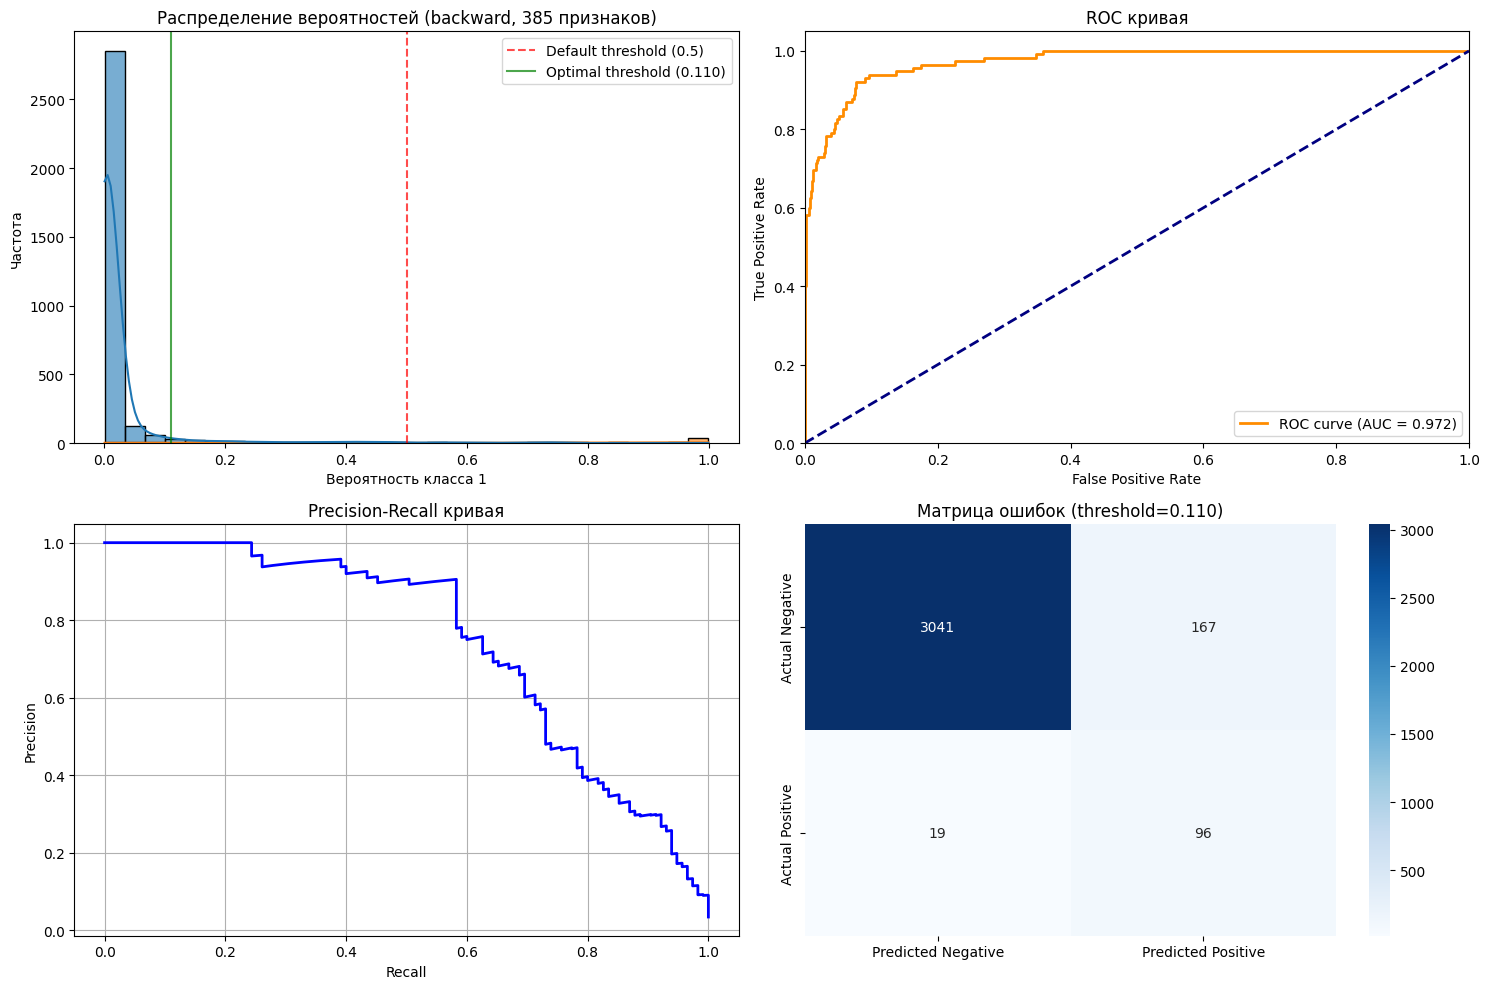

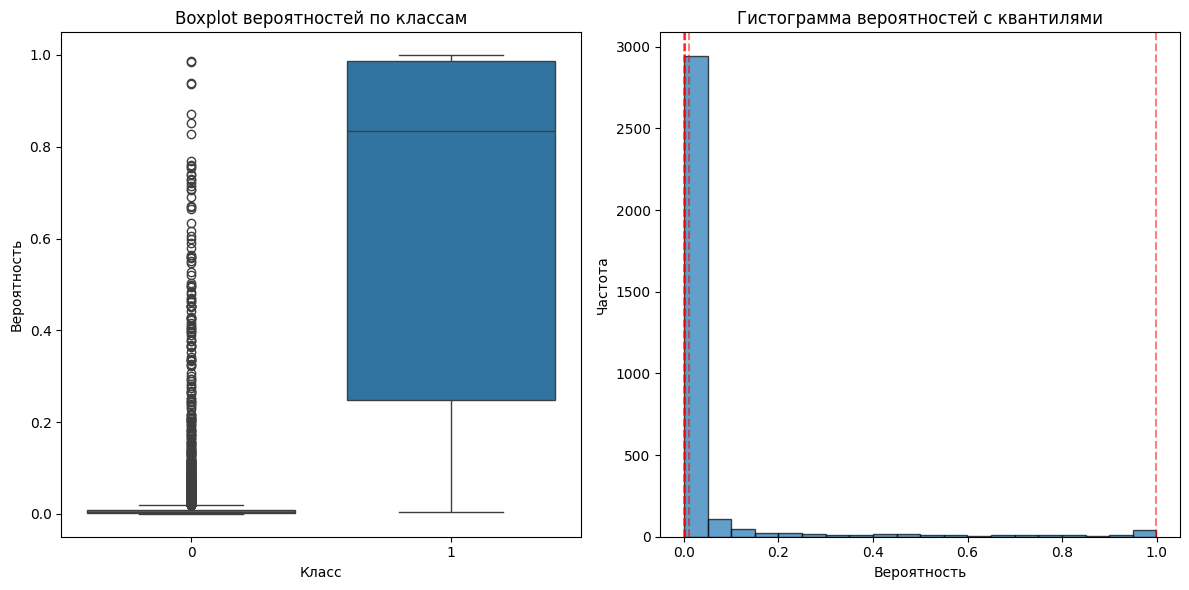

In [76]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [23]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 15
Лучшая f1: 0.4502
Признаки: ['Креатинин', 'СДЛА', 'UA_нестабильная_стенокардия', 'MKB', 'Нейтрофилы_абсолютное_значение', 'pCO2min_b', 'Apache_II', 'Стенокардия_в_диагнозе_при_поступлении', 'Фибриноген', 'Калий_K_a', 'Количество_пораженных_сосудов_Syntax', 'PAMI', 'Вазопрессорная_поддержка', 'Макс_АД_7_сут', 'ЧСС_а']

Важность признаков:
  Нейтрофилы_абсолютное_значение: 17.0429
  СДЛА: 13.3430
  ЧСС_а: 11.2985
  MKB: 8.9044
  PAMI: 8.4759
  Креатинин: 7.9228
  Калий_K_a: 7.4800
  Apache_II: 6.1383
  UA_нестабильная_стенокардия: 5.5559
  Стенокардия_в_диагнозе_при_поступлении: 4.6289
  Количество_пораженных_сосудов_Syntax: 4.5740
  pCO2min_b: 2.7403
  Фибриноген: 1.3748
  Вазопрессорная_поддержка: 0.4843
  Макс_АД_7_сут: 0.0358
=== Лучшие признаки (backward) ===
Количество признаков: 342
Лучшая f1: 0.4987
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид_STEMI', 'Инфаркт-зависимая_артерия

In [24]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9714 с 15 признаками
Лучший ROC AUC (Backward): 0.9648 с 342 признаками
Оптимальный порог для бинарной классификации: 0.2900


-----------------

In [25]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [26]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(xgb_model, max_features=None, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...


  0%|          | 1/343 [00:19<1:48:59, 19.12s/it, roc_auc=0.7900, Features=1]

Step 1: Добавлен признак 'Креатинин', roc_auc: 0.7900


  1%|          | 2/343 [00:43<2:04:47, 21.96s/it, roc_auc=0.8577, Features=2]

Step 2: Добавлен признак 'СДЛА', roc_auc: 0.8577


...

Step 10: Добавлен признак 'Открытая_перация_на_сердце_в_анамнезе', roc_auc: 0.9521


  3%|▎         | 11/343 [05:15<2:56:21, 31.87s/it, roc_auc=0.9528, Features=11]

Step 11: Добавлен признак 'Недостаточность_митрального_клапана_степень', roc_auc: 0.9528


  3%|▎         | 11/343 [05:48<2:55:32, 31.72s/it, roc_auc=0.9528, Features=11]

Step 12: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 11


In [27]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(xgb_model, min_features=1, metric='roc_auc')


=== BACKWARD ELIMINATION ===
Запуск Backward Elimination...


  0%|          | 1/342 [06:02<34:21:01, 362.64s/it, roc_auc=0.9669, Features=342]

Step 1: Удален признак 'Количество_дней_в_реанимации', roc_auc: 0.9669


  1%|          | 2/342 [12:10<34:31:44, 365.60s/it, roc_auc=0.9682, Features=341]

Step 2: Удален признак 'Ср_концентрация_гемоглобина_в_эритроците', roc_auc: 0.9682


...

Step 9: Удален признак 'ФП_b_после_чкв', roc_auc: 0.9690


  3%|▎         | 10/342 [59:22<32:23:02, 351.15s/it, roc_auc=0.9690, Features=333]

Step 10: Удален признак 'PO2VenMax', roc_auc: 0.9690


  3%|▎         | 10/342 [1:05:08<36:02:44, 390.86s/it, roc_auc=0.9690, Features=333]

Step 11: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 333



=== СРАВНЕНИЕ МЕТОДОВ ===


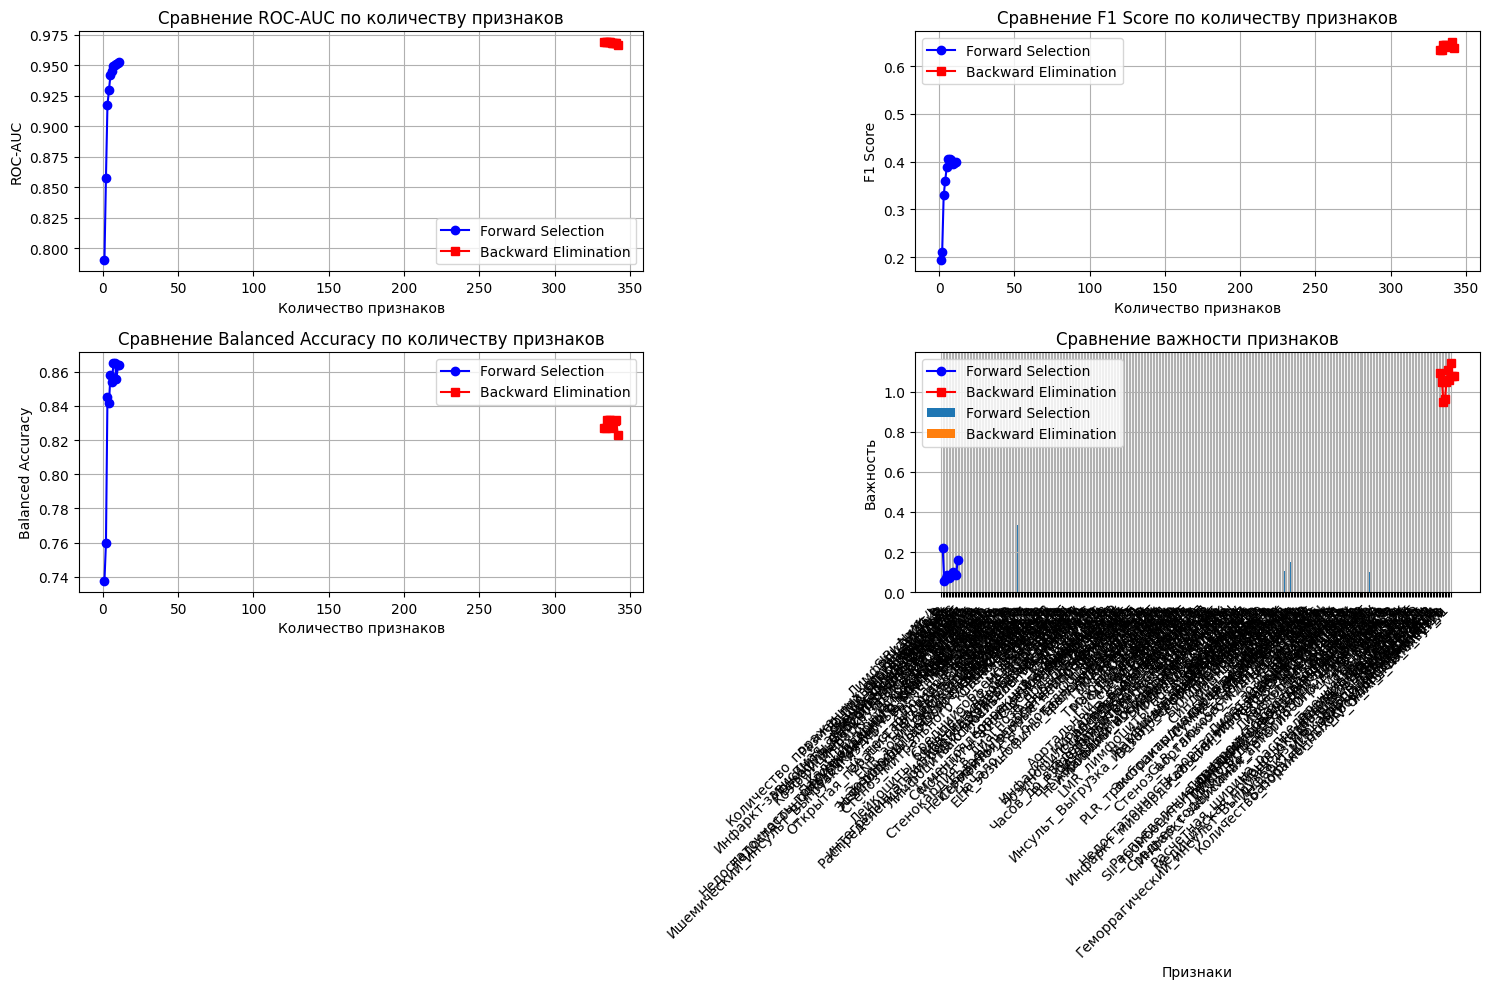

In [28]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [29]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 11 признаков) ===
По Balanced Accuracy score: 0.1900 (F1=0.8840)
По Youden's J: 0.1922


In [30]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 333 признаков) ===
По Balanced Accuracy score: 0.1100 (F1=0.8959)
По Youden's J: 0.0453



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


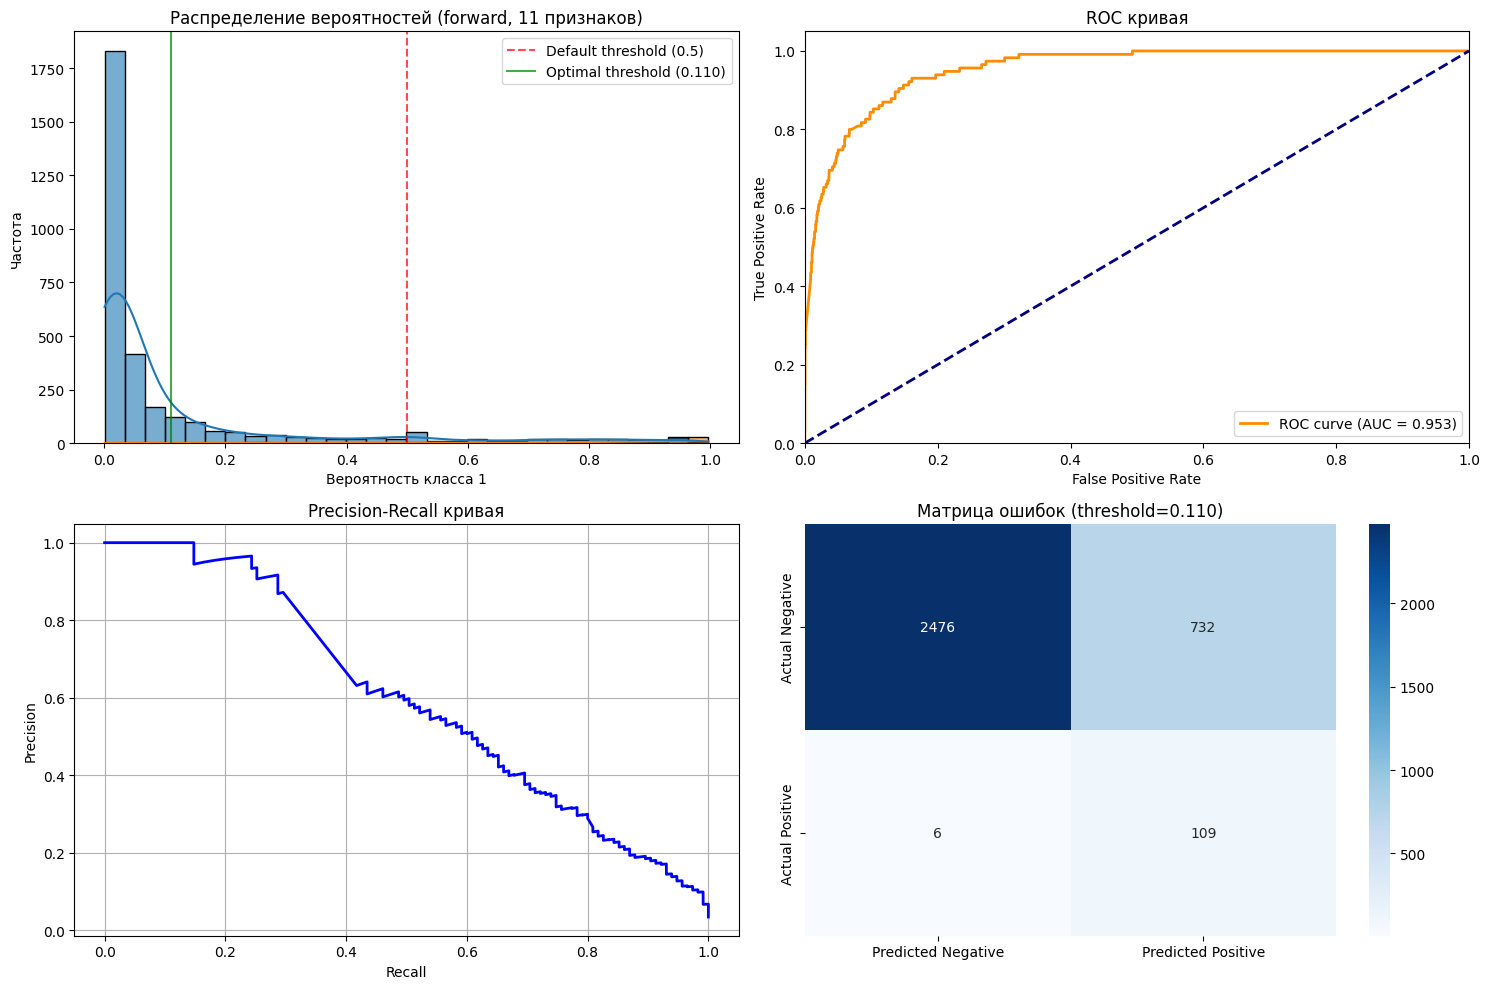

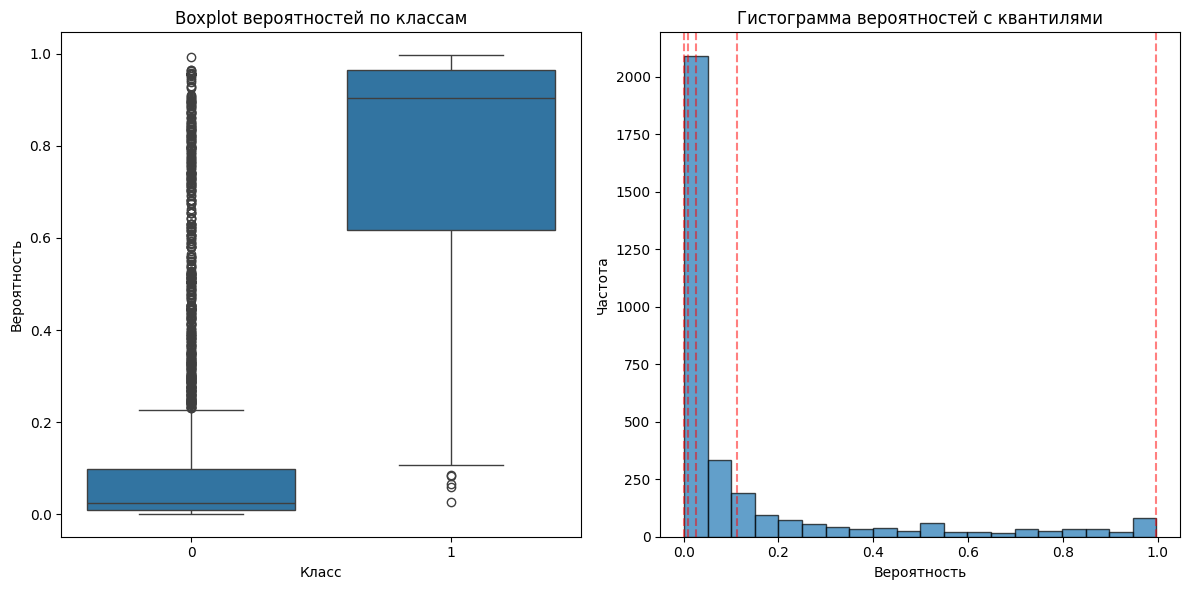

In [31]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


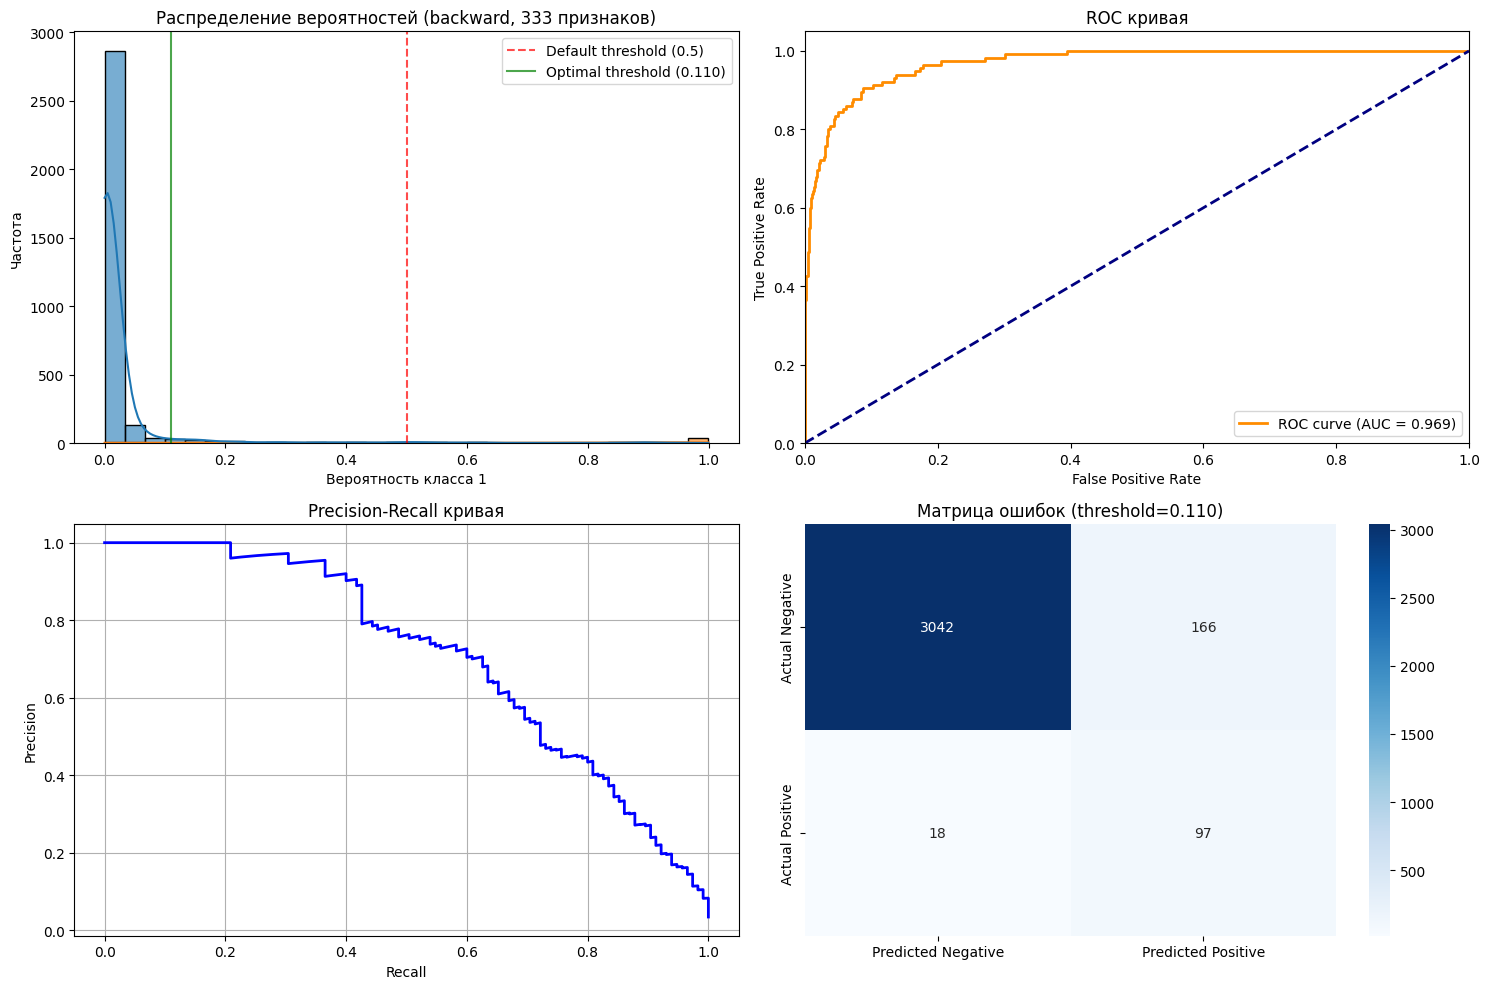

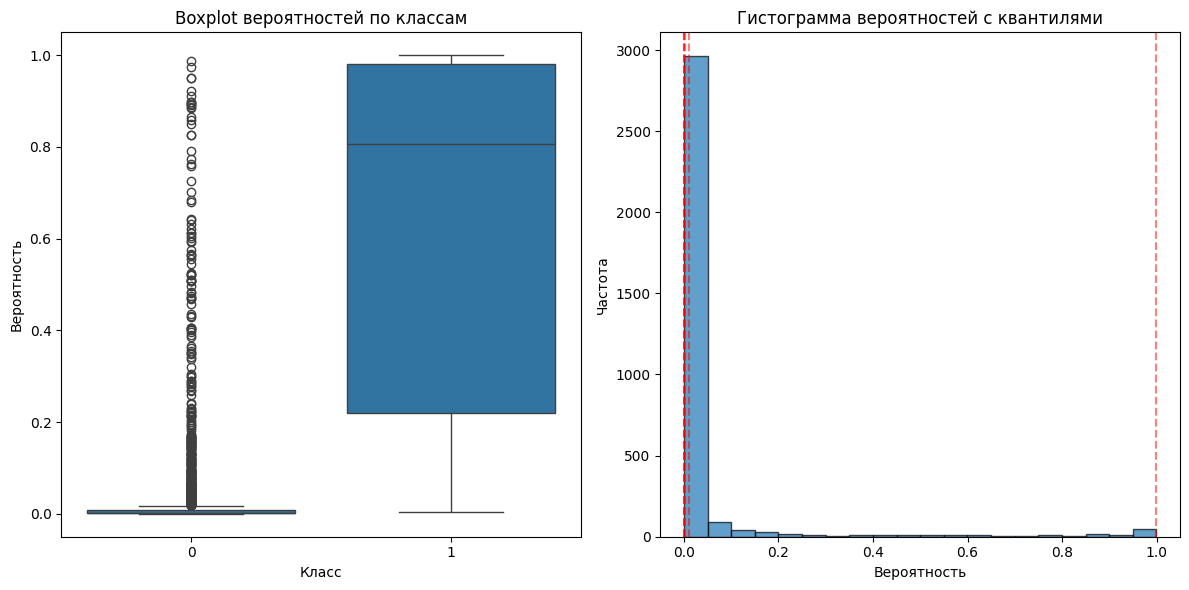

In [32]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [33]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 6
Лучшая f1: 0.4063
Признаки: ['Креатинин', 'СДЛА', 'UA_нестабильная_стенокардия', 'Apache_II', 'РЕКОРД', 'Нейтрофилы_абсолютное_значение_a']

Важность признаков:
  UA_нестабильная_стенокардия: 0.3372
  Нейтрофилы_абсолютное_значение_a: 0.1995
  РЕКОРД: 0.1510
  Apache_II: 0.1102
  СДЛА: 0.1038
  Креатинин: 0.0984
=== Лучшие признаки (backward) ===
Количество признаков: 341
Лучшая f1: 0.6500
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид_STEMI', 'Инфаркт-зависимая_артерия', 'Поражение_ствола', 'Количество_пораженных_сосудов_Syntax', 'Количество_пораженных_сосудов_Значимость', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Инфаркт_миокарда_в_анамнезе_gt_3', 'Инфаркт_миокарда_со_стентированием_в_анамнезе', 'ОНМК_иш_в_анамнезе', 'ОНМК_гем_в_анамнезе', 'Стентирование_в_анамнезе', 'Тромболизис', 'Форма_ФП', 'Калий', 'Дилатация_предсердий', 'ФП_b_после_чкв', 'ФП_a_в_анамнезе', 'ФП_при_окс_до_чкв', 'ФП_по

In [34]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9457 с 6 признаками
Лучший ROC AUC (Backward): 0.9682 с 341 признаками
Оптимальный порог для бинарной классификации: 0.1100


In [35]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [ ]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(lgb_model, max_features=None, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...


  0%|          | 0/343 [00:00<?, ?it/s]

In [ ]:
print("=== BACKWARD SELECTION ===")
forward_features = analyzer.backward_elimination(lgb_model, min_features=1, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== BACKWARD SELECTION ===
Запуск Backward Elimination...


  0%|          | 1/391 [03:54<25:25:00, 234.62s/it, roc_auc=0.9749, Features=391]

Step 1: Удален признак 'АСАТ_a', roc_auc: 0.9749


  1%|          | 2/391 [07:48<25:16:39, 233.93s/it, roc_auc=0.9768, Features=390]

Step 2: Удален признак 'pHARTmin_b', roc_auc: 0.9768


...

Step 9: Удален признак 'ФП_b_после_чкв', roc_auc: 0.9785


  3%|▎         | 10/391 [38:00<23:39:22, 223.52s/it, roc_auc=0.9785, Features=382]

Step 10: Удален признак 'ФВ_ЛЖ_b', roc_auc: 0.9785


  3%|▎         | 10/391 [41:41<26:28:31, 250.16s/it, roc_auc=0.9785, Features=382]

Step 11: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 382


In [277]:
1

1


=== СРАВНЕНИЕ МЕТОДОВ ===


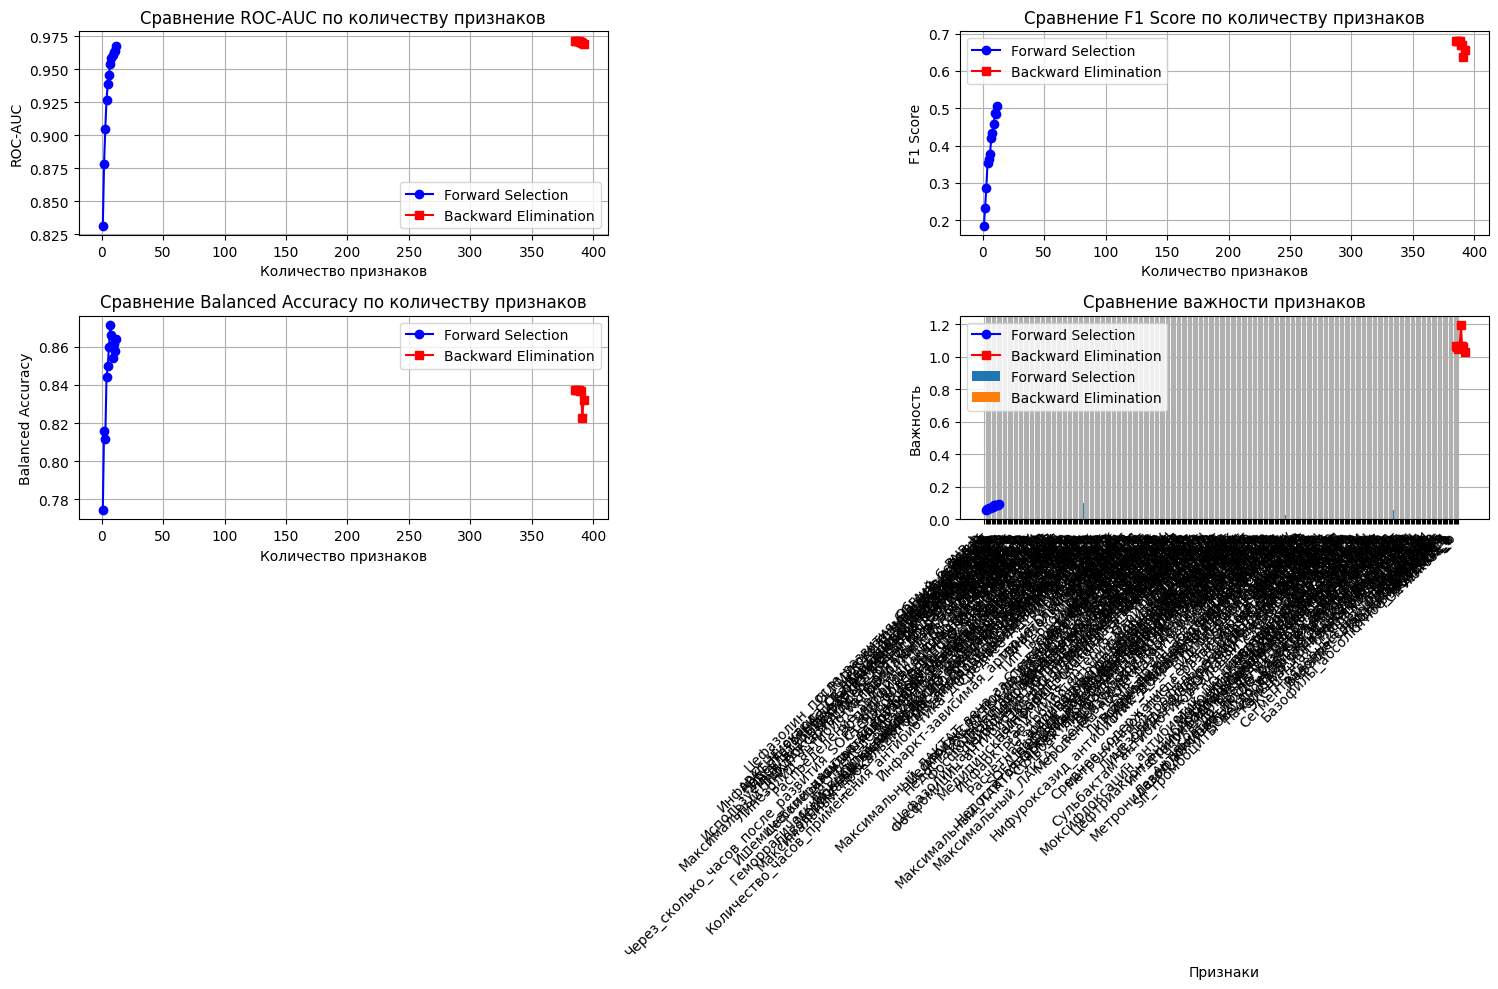

In [79]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [80]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 12 признаков) ===
По Balanced Accuracy score: 0.1700 (F1=0.9084)
По Youden's J: 0.1861


In [81]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 385 признаков) ===
По Balanced Accuracy score: 0.1100 (F1=0.8914)
По Youden's J: 0.0601



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


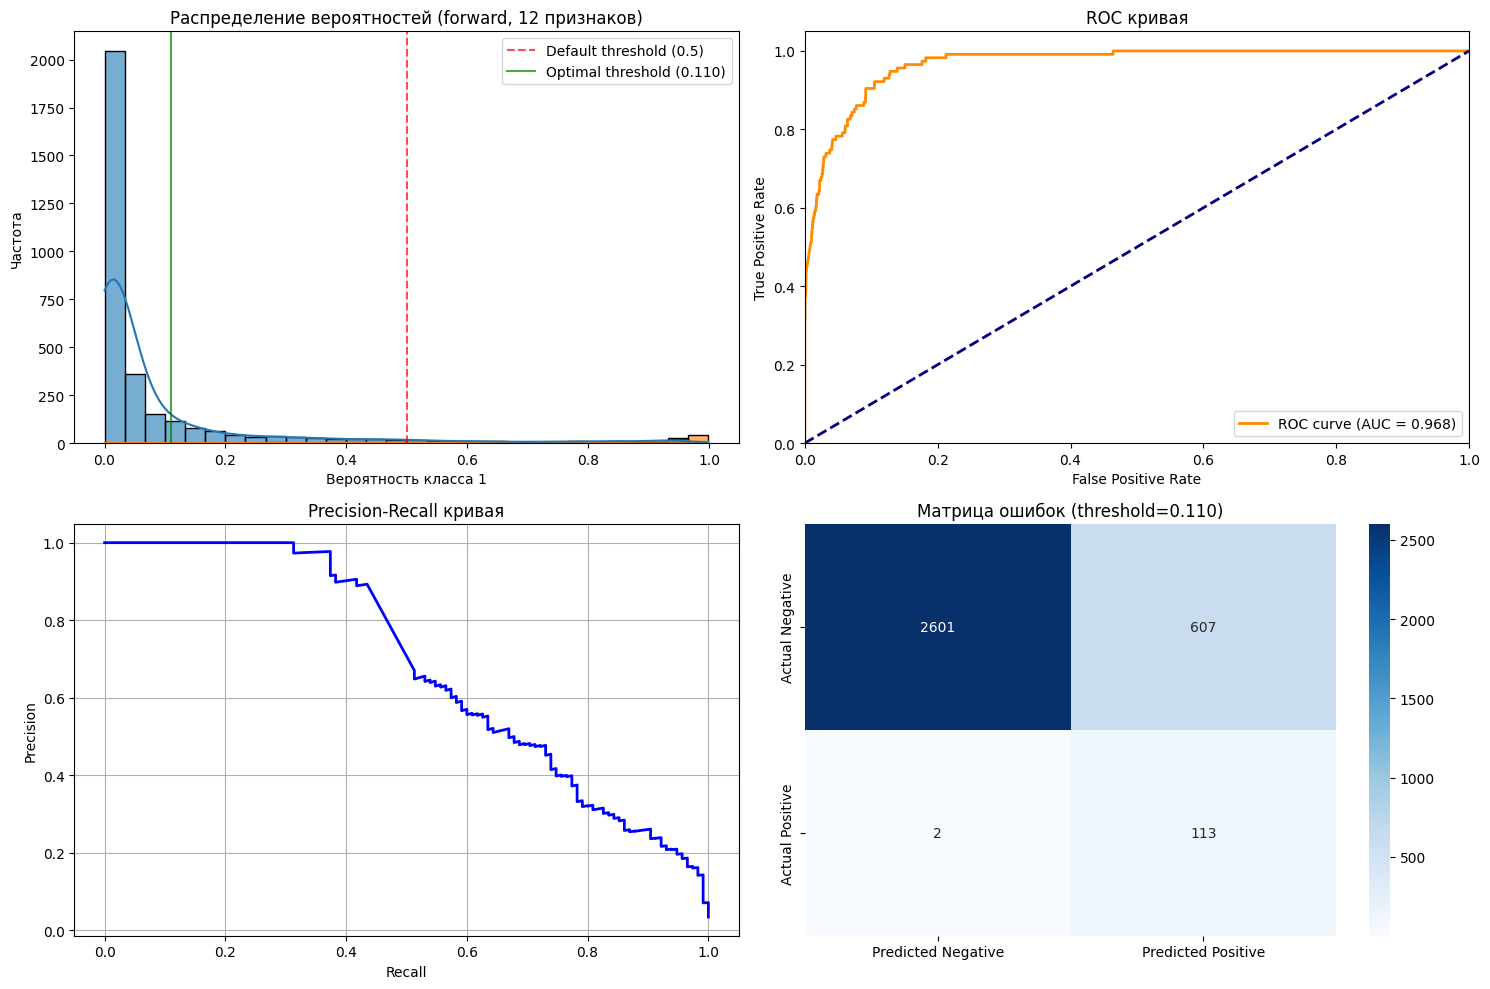

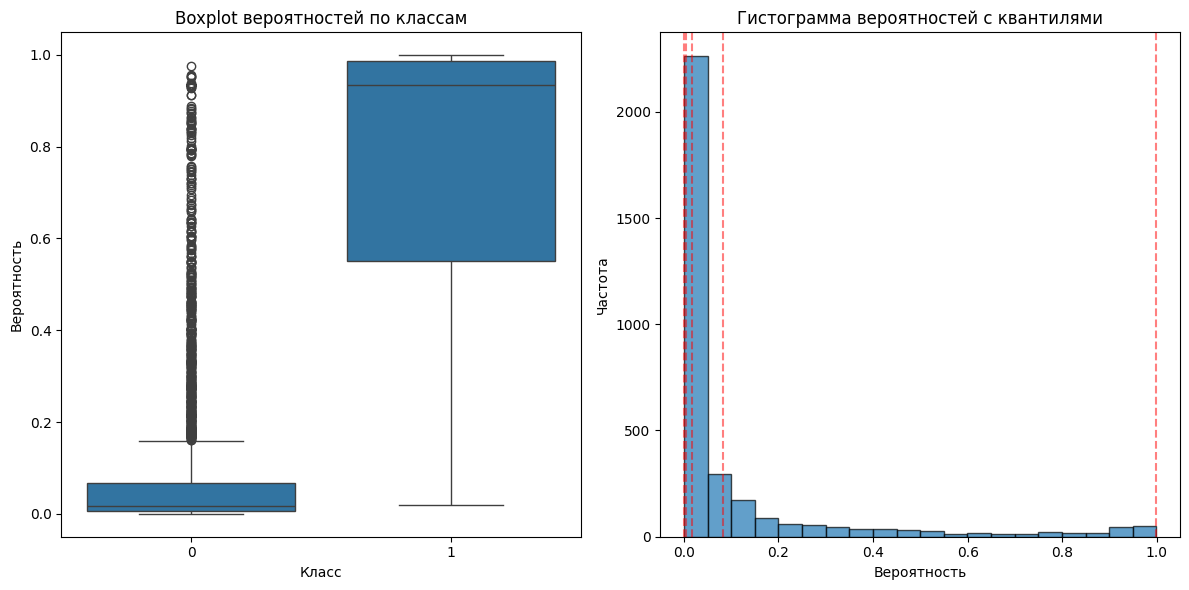

In [82]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


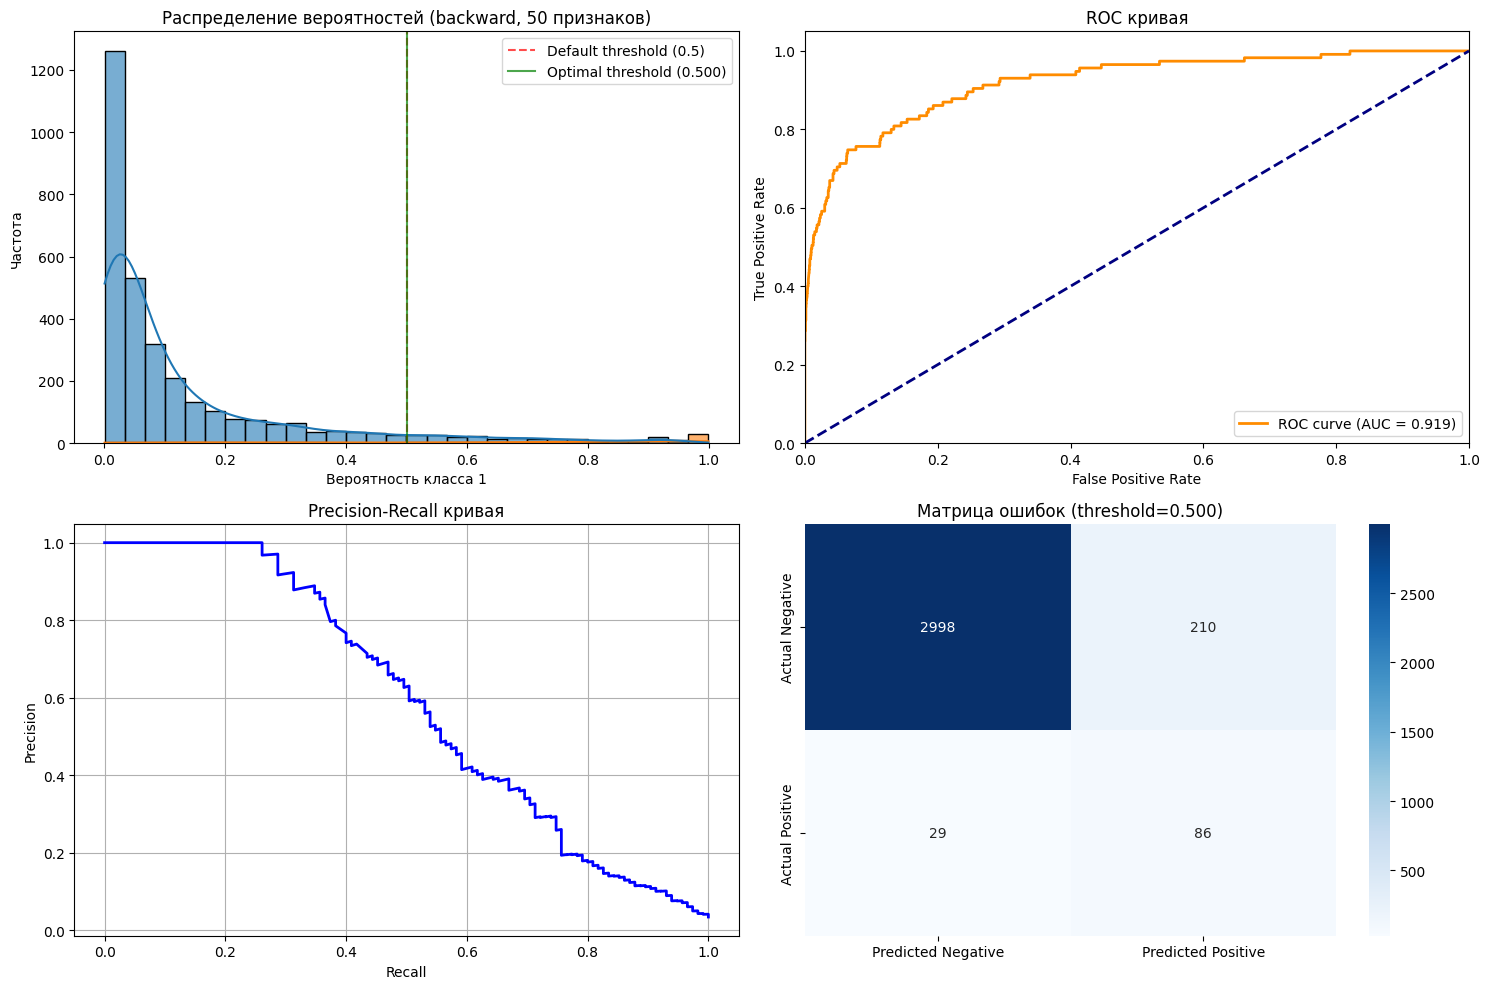

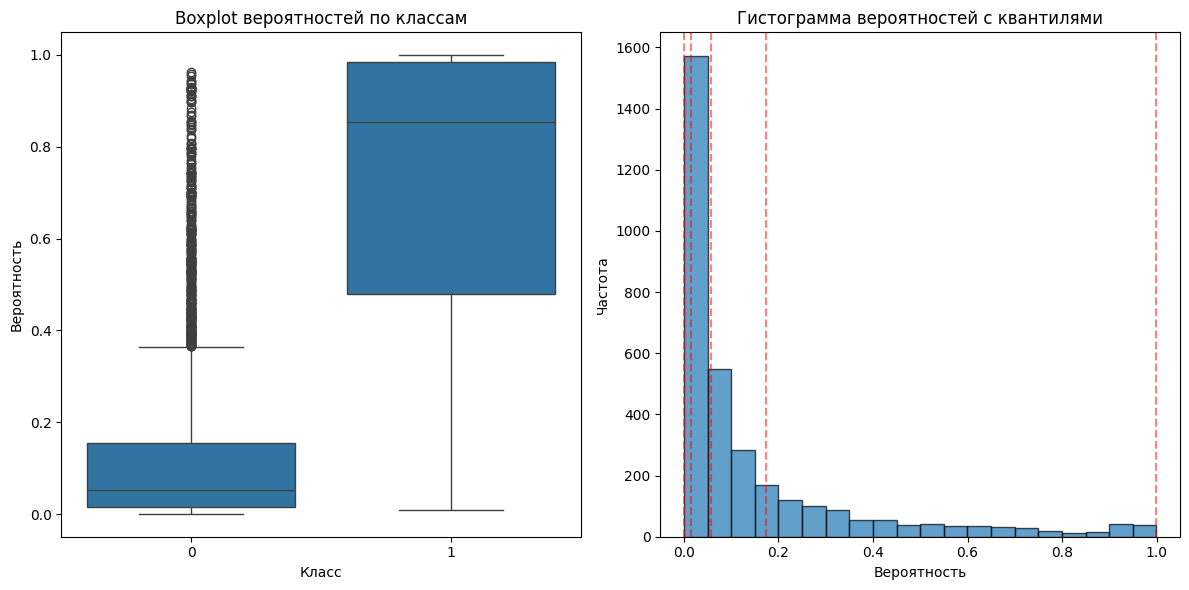

In [ ]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [83]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 12
Лучшая f1: 0.5057
Признаки: ['Мочевина_a', 'ЧСС_b', 'Apache_II', 'Моноциты_абсолютное_значение', 'ФВ_ЛЖ_b', 'СДЛА', 'killip', 'HCO3ArtMax_a', 'STEMI', 'Курит', 'TIMI_Летальность', 'ПСПЖ']

Важность признаков:
  Мочевина_a: 0.2482
  STEMI: 0.2035
  killip: 0.0987
  Apache_II: 0.0862
  СДЛА: 0.0690
  Курит: 0.0612
  ЧСС_b: 0.0492
  ПСПЖ: 0.0457
  TIMI_Летальность: 0.0429
  Моноциты_абсолютное_значение: 0.0425
  ФВ_ЛЖ_b: 0.0266
  HCO3ArtMax_a: 0.0262
=== Лучшие признаки (backward) ===
Количество признаков: 388
Лучшая f1: 0.6810
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид_STEMI', 'Инфаркт-зависимая_артерия', 'Поражение_ствола', 'Количество_пораженных_сосудов_Syntax', 'TIMI', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Инфаркт_миокарда_в_анамнезе_gt_3', 'Инфаркт_миокарда_со_стентированием_в_анамнезе', 'ОНМК_иш_в_анамнезе', 'ОНМК_гем_в_анамнезе', 'Стентирование_в_анамнезе', 'Тромболизис', 'Форма

In [84]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9675 с 12 признаками
Лучший ROC AUC (Backward): 0.9716 с 388 признаками
Оптимальный порог для бинарной классификации: 0.1100


In [78]:
print("All worked out")

All worked out
